# CART MODELS FOR CREDIT EVALUATION

## IMPORTS AND DATA PREPARATION

### IMPORTS

In [1]:
# file-path handling
from pathlib import Path

# Utilities for data management
import numpy as np
import pandas as pd

# CART model class and imputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

# Chart plotting
import matplotlib.pyplot as plt
import seaborn as sns

### PATHS

In [2]:
# Paths to train / validate / test data
OUTPUT_DIR = Path("../data")
TRAIN_PATH = OUTPUT_DIR / "train.csv"
VALIDATE_PATH = OUTPUT_DIR / "validate.csv"
TEST_PATH = OUTPUT_DIR / "test.csv"

# Paths to cart model outputs
CART_OUTPUT_DIR = Path("../output/cart")
CART_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALIDATION_COMPARE_CSV = CART_OUTPUT_DIR / "cart_validation_comparison.csv" 

### DATA VALIDATION

In [3]:
# Load data splits to pandas (no low mem for better typing when loading to df)
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

# Data shape prints (samples, features)
print("Train shape:   ", train_df.shape)
print("Validate shape:", validate_df.shape)
print("Test shape:    ", test_df.shape)

Train shape:    (215137, 33)
Validate shape: (46101, 33)
Test shape:     (46101, 33)


In [4]:
# Create resuable constants for label and ID
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

# Confirm features and order consistent across splits
print("Train/validate columns match:", list(train_df.columns) == list(validate_df.columns))
print("Train/test columns match:    ", list(train_df.columns) == list(test_df.columns))

Train/validate columns match: True
Train/test columns match:     True


### PREP DATA FOR MODEL TRAINING

##### Separate labels

In [5]:
# Separate labels y
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val = validate_df[TARGET_COLUMN].astype(int).copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

# Remove labels and IDs to prep samples for training
X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

##### Convert categorical to one-hot encodings

In [6]:
# Store list of categorical vs num features
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# One-hot encode categorical columns with pd.get_dummies (including "MISSING")
X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, drop_first=False, dtype=int)
X_val_encoded = pd.get_dummies(X_val, columns=categorical_columns, drop_first=False, dtype=int)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_columns, drop_first=False, dtype=int)

# Align columns
X_train_ready = X_train_encoded.copy()
X_val_ready = X_val_encoded.reindex(columns=X_train_ready.columns, fill_value=0)
X_test_ready = X_test_encoded.reindex(columns=X_train_ready.columns, fill_value=0)

# Scikit-learn DecisionTreeClassifier handles explicit NaNs differently, so we use SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train_ready), columns=X_train_ready.columns)
X_val_ready = pd.DataFrame(imputer.transform(X_val_ready), columns=X_val_ready.columns)
X_test_ready = pd.DataFrame(imputer.transform(X_test_ready), columns=X_test_ready.columns)

print("Final shapes after imputation:")
print("X_train_ready:", X_train_ready.shape)
print("X_val_ready:  ", X_val_ready.shape)

Final shapes after imputation:
X_train_ready: (215137, 127)
X_val_ready:   (46101, 127)


## EVALUATION METRICS

In [7]:
# Helper func to compute KS stat for binary classification
def compute_ks(y_true, y_score):
    df_ks = pd.DataFrame({"y_true": pd.Series(y_true).reset_index(drop=True), "y_score": pd.Series(y_score).reset_index(drop=True)})
    df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)
    total_positives = (df_ks["y_true"] == 1).sum()
    total_negatives = (df_ks["y_true"] == 0).sum()
    if total_positives == 0 or total_negatives == 0: return np.nan
    df_ks["cum_positives"] = (df_ks["y_true"] == 1).cumsum() / total_positives
    df_ks["cum_negatives"] = (df_ks["y_true"] == 0).cumsum() / total_negatives
    return np.max(np.abs(df_ks["cum_positives"] - df_ks["cum_negatives"]))

def evaluate_binary_model(model, X, y, split_name, model_name):
    y_proba = model.predict_proba(X)[:, 1]
    return {
        "model_name": model_name,
        "split": split_name,
        "roc_auc": roc_auc_score(y, y_proba),
        "pr_auc": average_precision_score(y, y_proba),
        "brier_score": brier_score_loss(y, y_proba),
        "ks_stat": compute_ks(y, y_proba)
    }

def plot_roc_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc_score(y_true, y_proba):.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_pr_curves(curves_dict, title):
    plt.figure(figsize=(8, 6))
    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {average_precision_score(y_true, y_proba):.4f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## UNCONSTRAINED CART MODEL

In [8]:
# Tune and fit unconstrained CART baseline model
from sklearn.model_selection import ParameterGrid
from IPython.display import display

# We want the unconstrained model to capture deep nonlinear feature interactions.
# We do a grid search over larger depths and select the best model on PR-AUC.
param_grid = {
    'max_depth': [8, 12, 16, 20, None],
    'min_samples_leaf': [10, 50, 100]
}

best_pr_auc = -1
best_cart_unconstrained = None
search_results = []

for params in ParameterGrid(param_grid):
    clf = DecisionTreeClassifier(**params, random_state=42)
    clf.fit(X_train_ready, y_train)
    
    # Evaluate on validation
    # Use str(params['max_depth']) because None raises formatting issues sometimes
    model_lbl = f"cart_unconstrained_d{params['max_depth']}_l{params['min_samples_leaf']}"
    val_res = evaluate_binary_model(clf, X_val_ready, y_val, "validation", model_lbl)
    search_results.append(val_res)
    
    if val_res['pr_auc'] > best_pr_auc:
        best_pr_auc = val_res['pr_auc']
        best_cart_unconstrained = clf

search_results_df = pd.DataFrame(search_results).sort_values(by='pr_auc', ascending=False)
print("Top 5 Unconstrained Configurations:")
display(search_results_df.head())

# Lock the best unconstrained model
cart_baseline = best_cart_unconstrained

# Evaluate
baseline_val_prob = cart_baseline.predict_proba(X_val_ready)[:, 1]
baseline_val_result = evaluate_binary_model(cart_baseline, X_val_ready, y_val, "validation", "cart_unconstrained_best")
print("\nBest Unconstrained Validation Results:", baseline_val_result)


Top 5 Unconstrained Configurations:


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat
2,cart_unconstrained_d8_l100,validation,0.718238,0.195372,0.070041,0.321579
1,cart_unconstrained_d8_l50,validation,0.716251,0.194256,0.070169,0.318882
0,cart_unconstrained_d8_l10,validation,0.717384,0.191799,0.070388,0.326470
5,cart_unconstrained_d12_l100,validation,0.702362,0.188660,0.071081,0.308383
8,cart_unconstrained_d16_l100,validation,0.689756,0.183545,0.071848,0.286432



Best Unconstrained Validation Results: {'model_name': 'cart_unconstrained_best', 'split': 'validation', 'roc_auc': np.float64(0.7182375756934248), 'pr_auc': np.float64(0.19537161868327813), 'brier_score': np.float64(0.0700411333559675), 'ks_stat': 0.3215786376610571}


## CONSTRAINED CART MODEL

Apply monotonic constraints to features that should logically reduce risk (e.g., higher income, better credit scores).

In [9]:
# Map Monotonic Constraints 
# -1 for negative correlation with default risk, 1 for positive, 0 for none
EXT_SOURCE_COLUMNS = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

mono_cst = []
for col in X_train_ready.columns:
    if col in EXT_SOURCE_COLUMNS:
        mono_cst.append(-1)
    elif col in ['AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED']:
        mono_cst.append(-1)
    else:
        mono_cst.append(0)

# Constrained model with severely restricted depth (highly interpretable scorecard-like tree)
cart_constrained = DecisionTreeClassifier(
    max_depth=4,              # Explicitly restricted depth matching realistic banking constraints
    min_samples_leaf=100,     # Robust leaf nodes
    random_state=42,
    monotonic_cst=mono_cst
)

cart_constrained.fit(X_train_ready, y_train)

constrained_val_prob = cart_constrained.predict_proba(X_val_ready)[:, 1]
constrained_val_result = evaluate_binary_model(cart_constrained, X_val_ready, y_val, "validation", "cart_constrained")
print("Constrained validation results:", constrained_val_result)


Constrained validation results: {'model_name': 'cart_constrained', 'split': 'validation', 'roc_auc': np.float64(0.698372836155366), 'pr_auc': np.float64(0.16611436144616207), 'brier_score': np.float64(0.07080701101194763), 'ks_stat': 0.31022732622621546}


## COMPARISON & PLOTS

In [10]:
validation_compare_df = pd.DataFrame([baseline_val_result, constrained_val_result])
validation_compare_df.to_csv(VALIDATION_COMPARE_CSV, index=False)
display(validation_compare_df)

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat
0,cart_unconstrained_best,validation,0.718238,0.195372,0.070041,0.321579
1,cart_constrained,validation,0.698373,0.166114,0.070807,0.310227


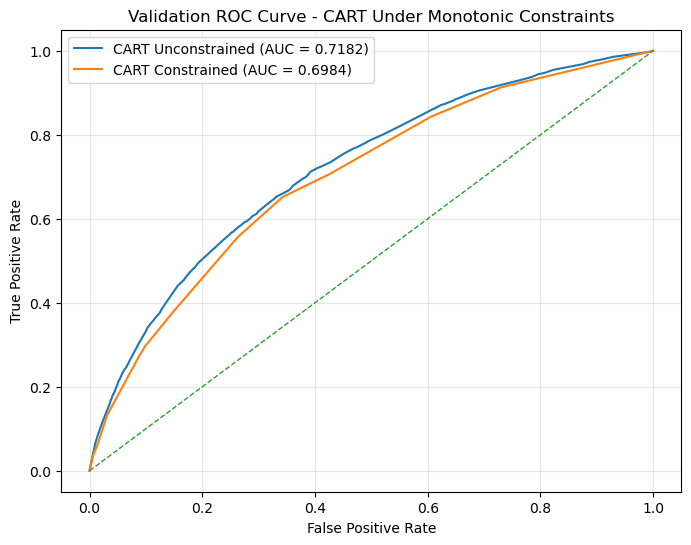

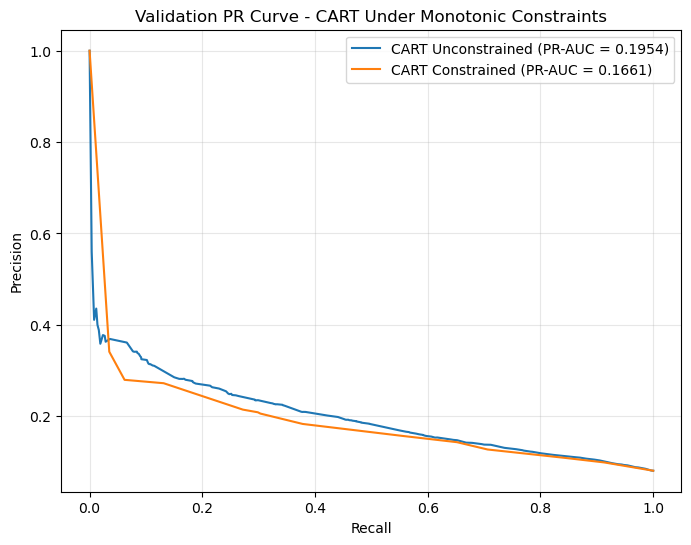

In [11]:
# Validation comparison plots: ROC & PR for unconstrained vs constrained CART

plot_roc_curves(
    curves_dict={
        "CART Unconstrained": (y_val, baseline_val_prob),
        "CART Constrained": (y_val, constrained_val_prob)
    },
    title="Validation ROC Curve - CART Under Monotonic Constraints"
)

plot_pr_curves(
    curves_dict={
        "CART Unconstrained": (y_val, baseline_val_prob),
        "CART Constrained": (y_val, constrained_val_prob)
    },
    title="Validation PR Curve - CART Under Monotonic Constraints"
)

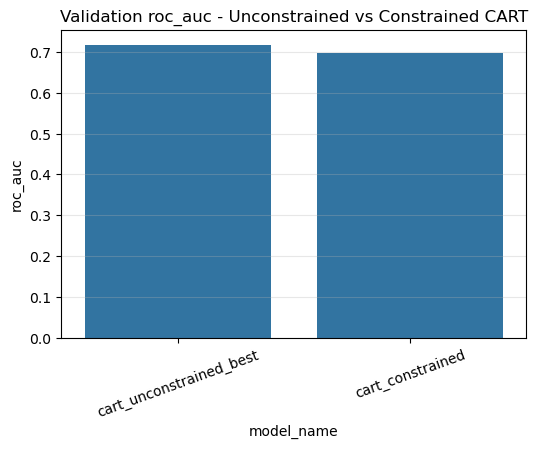

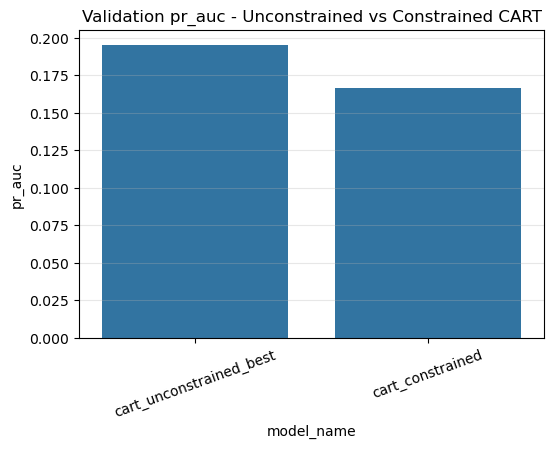

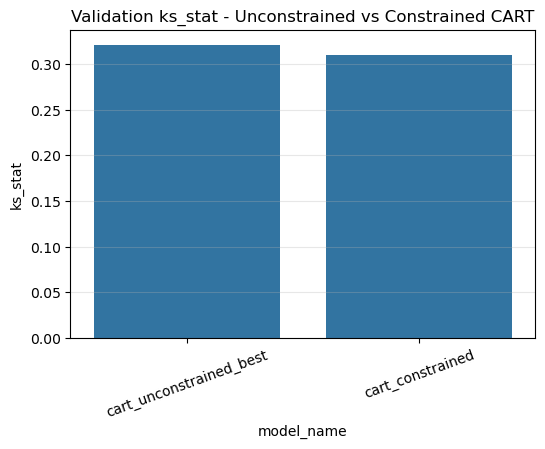

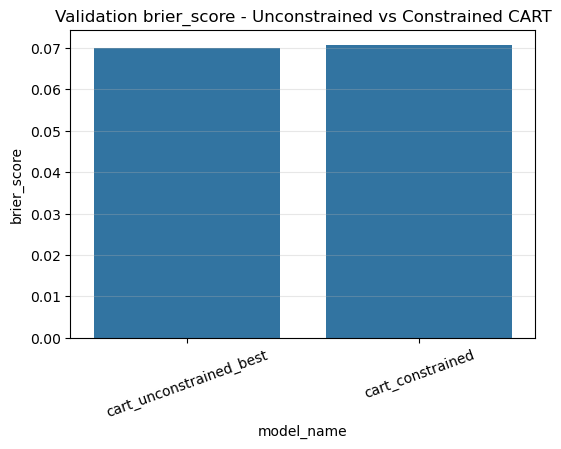

In [12]:
metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]

for metric in metrics_to_plot:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=validation_compare_df, x="model_name", y=metric)
    plt.title(f"Validation {metric} - Unconstrained vs Constrained CART")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()